# Tugas - Klasifikasi dengan Support Vector Machine (SVM)

| Nama | NRP |
|------|-----|
| Rayyan Muhtar Ali | 5054251051 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model SVM Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

Tujuan utama dari tugas ini adalah memahami cara kerja SVM secara praktik, khususnya:
1. Perbedaan hasil antara kernel Linear dan kernel RBF
2. Pengaruh parameter `C` dan `gamma` terhadap gejala overfitting/underfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model SVM dengan kernel Linear dan kernel RBF.
   - Lakukan eksperimen regularisasi dengan variasi nilai `C` dan `gamma`.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [2]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)


In [3]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
data = pd.read_csv('data.csv')

print('jumlah baris dan kolom :', data.shape)
data.head()


jumlah baris dan kolom : (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
# 30 fitur jadi describe-nya di-transpose biar kebaca
data.describe().T


,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [6]:
# cek missing value dan duplikat
print('missing value per kolom, diambil yang > 0 :')
print(data.isna().sum()[data.isna().sum() > 0])
print()
print('jumlah baris duplikat :', data.duplicated().sum())
print('jumlah id unik        :', data['id'].nunique(), 'dari', len(data), 'baris')


missing value per kolom, diambil yang > 0 :
Unnamed: 32    569
dtype: int64

jumlah baris duplikat : 0
jumlah id unik        : 569 dari 569 baris


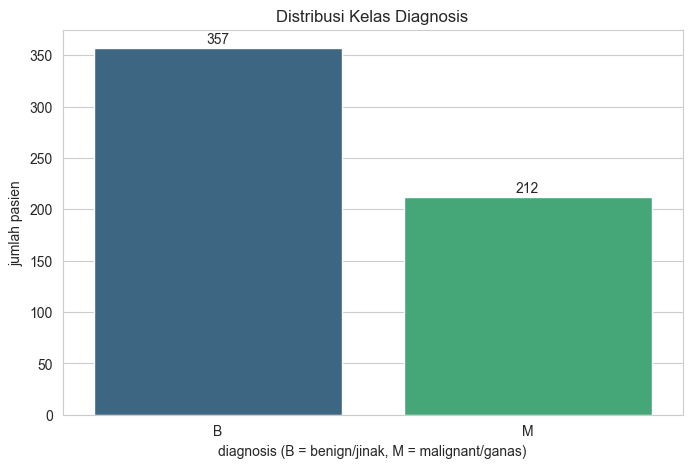

diagnosis
B    357
M    212
Name: count, dtype: int64

proporsi tiap kelas (%) :
diagnosis
B    62.74
M    37.26
Name: proportion, dtype: float64

rasio :  1 : 1.68


In [7]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
jumlah = data['diagnosis'].value_counts()

ax = sns.barplot(x=jumlah.index, y=jumlah.values, hue=jumlah.index, palette='viridis', legend=False)
for i, v in enumerate(jumlah.values):
    ax.text(i, v + 5, str(v), ha='center')
plt.title('Distribusi Kelas Diagnosis')
plt.xlabel('diagnosis (B = benign/jinak, M = malignant/ganas)')
plt.ylabel('jumlah pasien')
plt.show()

print(jumlah)
print()
print('proporsi tiap kelas (%) :')
print((data['diagnosis'].value_counts(normalize=True) * 100).round(2))
print()
# 63:37 masih termasuk cukup seimbang, jauh beda dengan dataset bankruptcy di tugas decision tree
# yang kelas minoritasnya cuma 3%, jadi di sini accuracy masih lumayan bisa dipakai
print('rasio :  1 :', round(jumlah['B'] / jumlah['M'], 2))


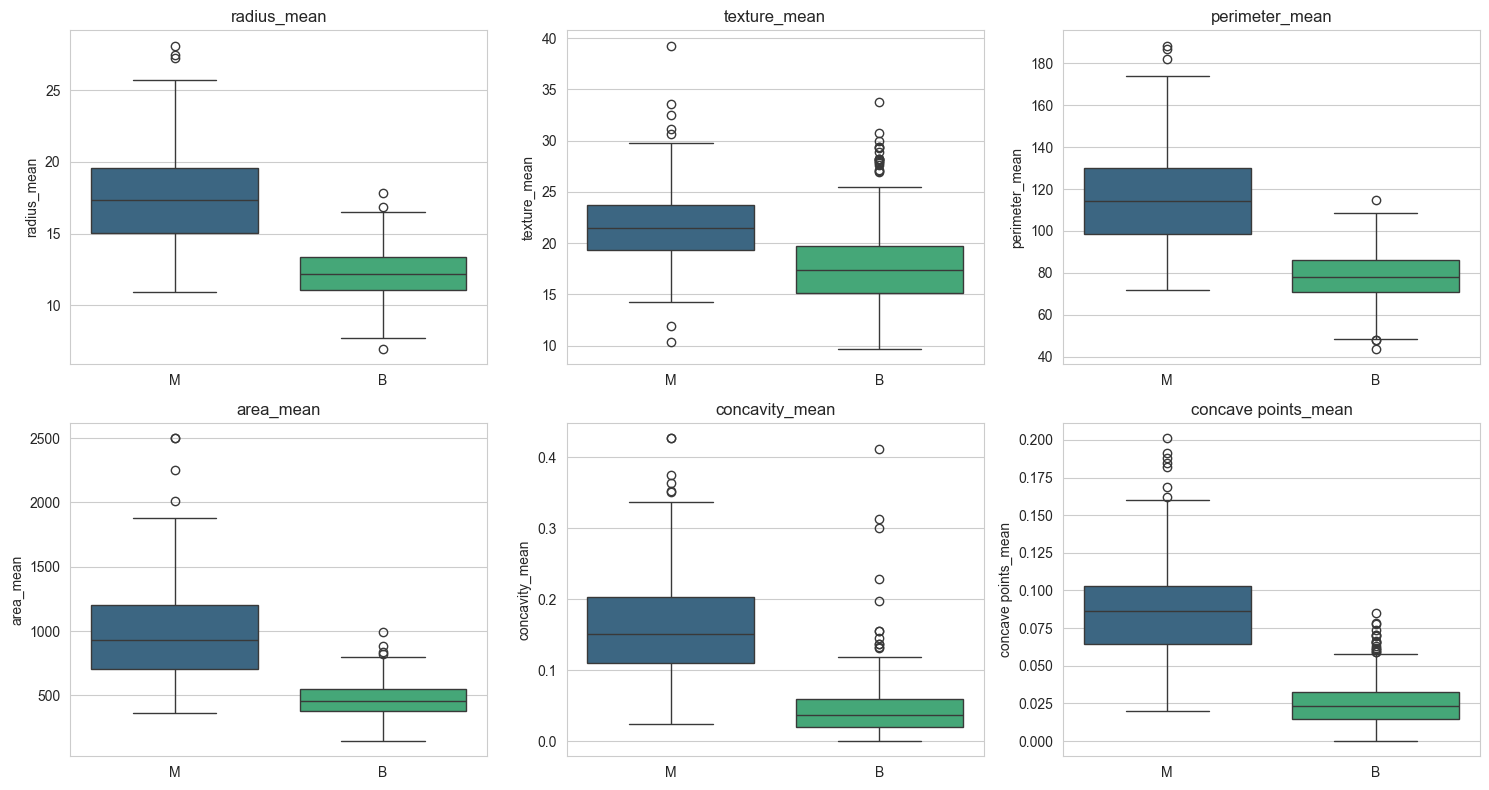

In [8]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas (linear) antar kelas, atau justru tumpang tindih.
# ambil 6 fitur _mean yang paling sering disebut sebagai pembeda, lihat sebarannya per kelas
fitur_lihat = ['radius_mean', 'texture_mean', 'perimeter_mean',
               'area_mean', 'concavity_mean', 'concave points_mean']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, kolom in zip(axes.flatten(), fitur_lihat):
    sns.boxplot(x='diagnosis', y=kolom, data=data, hue='diagnosis',
                palette='viridis', legend=False, ax=ax)
    ax.set_title(kolom)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

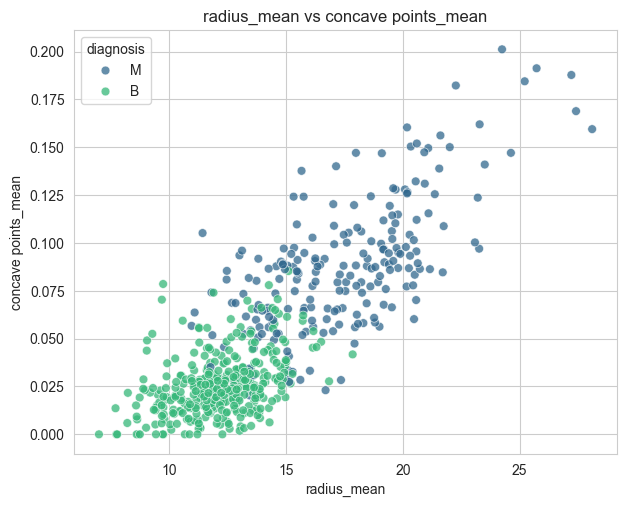

In [9]:
# scatter dua fitur yang pemisahannya paling kelihatan, buat menebak apakah datanya bisa
# dipisah garis lurus atau enggak. ini penting karena nanti dibandingkan kernel linear vs rbf
plt.figure(figsize=(7, 5.5))
sns.scatterplot(x='radius_mean', y='concave points_mean', hue='diagnosis',
                data=data, palette='viridis', alpha=0.75, s=40)
plt.title('radius_mean vs concave points_mean')
plt.show()


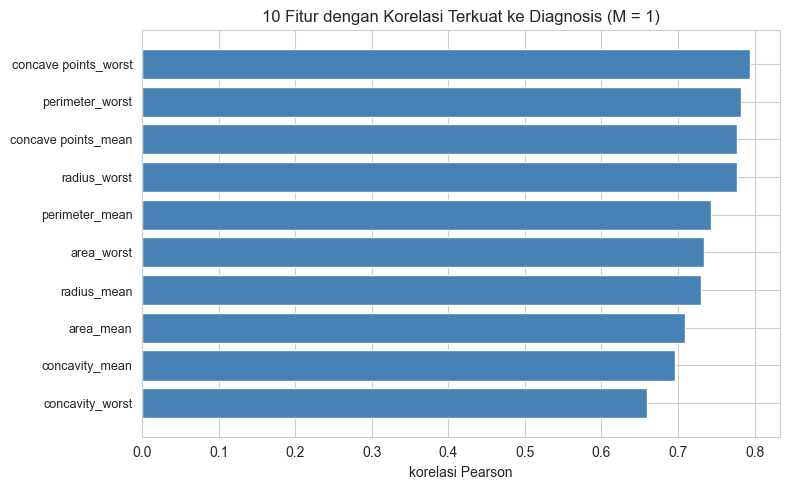

concave points_worst    0.7936
perimeter_worst         0.7829
concave points_mean     0.7766
radius_worst            0.7765
perimeter_mean          0.7426
area_worst              0.7338
radius_mean             0.7300
area_mean               0.7090
concavity_mean          0.6964
concavity_worst         0.6596
dtype: float64


In [10]:
# korelasi 10 fitur teratas terhadap diagnosis (M dianggap 1)
target_angka = (data['diagnosis'] == 'M').astype(int)
fitur_saja = data.drop(columns=['id', 'diagnosis', 'Unnamed: 32'])
korelasi_target = fitur_saja.corrwith(target_angka).sort_values()

top10 = korelasi_target.abs().sort_values(ascending=False).head(10).index
urut = korelasi_target[top10].sort_values()

plt.figure(figsize=(8, 5))
plt.barh(range(len(urut)), urut.values, color='steelblue')
plt.yticks(range(len(urut)), urut.index, fontsize=9)
plt.title('10 Fitur dengan Korelasi Terkuat ke Diagnosis (M = 1)')
plt.xlabel('korelasi Pearson')
plt.tight_layout()
plt.show()

print(korelasi_target[top10].sort_values(ascending=False).round(4))


In [11]:
# ini yang paling penting buat SVM: rentang antar fitur beda jauh
rentang = fitur_saja.agg(['min', 'max', 'std']).T
rentang['rentang'] = rentang['max'] - rentang['min']
print('5 fitur dengan rentang terbesar :')
print(rentang.sort_values('rentang', ascending=False).head(5).round(4))
print()
print('5 fitur dengan rentang terkecil :')
print(rentang.sort_values('rentang').head(5).round(4))
print()
print('perbandingan rentang terbesar dibanding terkecil :',
      round(rentang['rentang'].max() / rentang['rentang'].min(), 1), 'kali')


5 fitur dengan rentang terbesar :
                     min     max       std   rentang
area_worst       185.200  4254.0  569.3570  4068.800
area_mean        143.500  2501.0  351.9141  2357.500
area_se            6.802   542.2   45.4910   535.398
perimeter_worst   50.410   251.2   33.6025   200.790
perimeter_mean    43.790   188.5   24.2990   144.710

5 fitur dengan rentang terkecil :
                           min     max     std  rentang
fractal_dimension_se    0.0009  0.0298  0.0026   0.0289
smoothness_se           0.0017  0.0311  0.0030   0.0294
fractal_dimension_mean  0.0500  0.0974  0.0071   0.0475
concave points_se       0.0000  0.0528  0.0062   0.0528
symmetry_se             0.0079  0.0790  0.0083   0.0711

perbandingan rentang terbesar dibanding terkecil : 140569.1 kali


# 2. Preprocessing

In [12]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
# kolom 'Unnamed: 32' isinya NaN di semua 569 baris, ini artefak koma di akhir tiap baris csv-nya,
# bukan fitur beneran. gak ada yang bisa diimputasi jadi langsung dibuang.
# kolom 'id' juga dibuang karena cuma nomor identitas pasien, kalau ikut dipakai malah jadi fitur palsu.
print('missing sebelum dibersihkan :', data.isna().sum().sum())

df = data.drop(columns=['Unnamed: 32', 'id'])

print('missing sesudah dibersihkan :', df.isna().sum().sum())
print('shape sesudah dibersihkan   :', df.shape)
print()
# karena penanganannya cuma buang kolom, gak ada statistik apa pun yang dihitung dari data,
# jadi gak ada risiko data leakage di tahap ini
print('sisa kolom :', list(df.columns[:5]), '...', list(df.columns[-3:]))


missing sebelum dibersihkan : 569
missing sesudah dibersihkan : 0
shape sesudah dibersihkan   : (569, 31)

sisa kolom : ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean'] ... ['concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [13]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# satu-satunya kolom non-numerik di sini cuma target 'diagnosis' yang isinya B dan M.
# M (ganas) dijadikan 1 karena itu kelas yang mau dideteksi, jadi precision/recall kelas 1
# nanti langsung terbaca sebagai performa mendeteksi tumor ganas.
print('kolom bertipe object :', list(df.select_dtypes(include=['object']).columns))
print()

df['diagnosis'] = (df['diagnosis'] == 'M').astype(int)

print('hasil encoding :')
print(df['diagnosis'].value_counts().sort_index())
print('(0 = benign/jinak, 1 = malignant/ganas)')
print()
print('semua kolom sudah numerik :', df.select_dtypes(exclude=[np.number]).empty)


kolom bertipe object : ['diagnosis']

hasil encoding :
diagnosis
0    357
1    212
Name: count, dtype: int64
(0 = benign/jinak, 1 = malignant/ganas)

semua kolom sudah numerik : True


In [14]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

print('X :', X.shape)
print('y :', y.shape)
print()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('data train :', X_train.shape)
print('data test  :', X_test.shape)
print()
print('proporsi kelas train (%) :')
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))
print()
print('proporsi kelas test (%) :')
print((y_test.value_counts(normalize=True).sort_index() * 100).round(2))
print()
print('jumlah kelas ganas di train :', (y_train == 1).sum(), '| di test :', (y_test == 1).sum())


X : (569, 30)
y : (569,)



data train : (455, 30)
data test  : (114, 30)

proporsi kelas train (%) :
diagnosis
0    62.64
1    37.36
Name: proportion, dtype: float64

proporsi kelas test (%) :
diagnosis
0    63.16
1    36.84
Name: proportion, dtype: float64

jumlah kelas ganas di train : 170 | di test : 42


**Catatan penting:** SVM adalah algoritma berbasis jarak (margin dihitung dari posisi antar titik data), sehingga sangat sensitif terhadap skala fitur. Fitur dengan rentang nilai besar bisa mendominasi perhitungan jarak meskipun sebenarnya tidak lebih penting. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [15]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
# scaler di-fit cuma pakai data train, data test tinggal di-transform.
# kalau scaler di-fit ke seluruh data sebelum split, mean dan std milik data test ikut kepakai
# dan itu sudah termasuk data leakage.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('mean train :', round(X_train_scaled.mean(), 6), '| std train :', round(X_train_scaled.std(), 6))
print('mean test  :', round(X_test_scaled.mean(), 6), '| std test  :', round(X_test_scaled.std(), 6))
print('(mean train harus mendekati 0 dan std mendekati 1, data test wajar kalau agak meleset)')


mean train :

 0.0 | std train : 1.0
mean test  : -0.024009 | std test  : 0.931126
(mean train harus mendekati 0 dan std mendekati 1, data test wajar kalau agak meleset)


# 3. Eksperimen Model

## 3.1 SVM dengan Kernel Linear

Kernel Linear mencari hyperplane pemisah berupa garis/bidang lurus, tanpa proyeksi ke dimensi yang lebih tinggi. Cocok digunakan sebagai baseline, terutama jika dari hasil EDA data terlihat cukup terpisah secara linear.

In [16]:
# Inisialisasi dan latih model SVC dengan kernel='linear' menggunakan train set (yang sudah discaling).
svm_linear = SVC(kernel='linear', C=1, random_state=42)
svm_linear.fit(X_train_scaled, y_train)

print('jumlah support vector per kelas :', svm_linear.n_support_)
print('total support vector            :', svm_linear.support_vectors_.shape[0],
      'dari', X_train_scaled.shape[0], 'data train')
print('akurasi train :', round(svm_linear.score(X_train_scaled, y_train), 4))
print('akurasi test  :', round(svm_linear.score(X_test_scaled, y_test), 4))


jumlah support vector per kelas : [19 19]
total support vector            : 38 dari 455 data train
akurasi train : 0.989
akurasi test  : 0.9649


In [17]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
pred_linear = svm_linear.predict(X_test_scaled)

print('10 prediksi pertama :', pred_linear[:10])
print('10 label asli       :', y_test.values[:10])
print()
print(classification_report(y_test, pred_linear, digits=4,
                            target_names=['benign (0)', 'malignant (1)']))


10 prediksi pertama : [0 1 0 0 0 0 1 0 0 0]
10 label asli       : [0 1 0 1 0 0 1 0 0 0]



               precision    recall  f1-score   support

   benign (0)     0.9474    1.0000    0.9730        72
malignant (1)     1.0000    0.9048    0.9500        42

     accuracy                         0.9649       114
    macro avg     0.9737    0.9524    0.9615       114
 weighted avg     0.9668    0.9649    0.9645       114



## 3.2 SVM dengan Kernel RBF

Kernel RBF (Radial Basis Function) memproyeksikan data ke ruang berdimensi lebih tinggi melalui kernel trick, sehingga mampu menangani batas keputusan yang non-linear.

In [18]:
# Inisialisasi dan latih model SVC dengan kernel='rbf' menggunakan train set.
# Gunakan nilai hyperparameter lain (C) yang sama seperti model Linear di atas, agar perbandingan adil.
# C dibikin sama persis dengan model linear (C=1) biar yang dibandingkan cuma efek kernelnya
svm_rbf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

print('gamma yang dipakai (scale)      :', round(svm_rbf._gamma, 6))
print('jumlah support vector per kelas :', svm_rbf.n_support_)
print('total support vector            :', svm_rbf.support_vectors_.shape[0],
      'dari', X_train_scaled.shape[0], 'data train')
print('akurasi train :', round(svm_rbf.score(X_train_scaled, y_train), 4))
print('akurasi test  :', round(svm_rbf.score(X_test_scaled, y_test), 4))


gamma yang dipakai (scale)      : 0.033333
jumlah support vector per kelas : [50 57]
total support vector            : 107 dari 455 data train
akurasi train : 0.9868
akurasi test  : 0.9737


In [19]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
pred_rbf = svm_rbf.predict(X_test_scaled)

print('10 prediksi pertama :', pred_rbf[:10])
print('10 label asli       :', y_test.values[:10])
print()
print(classification_report(y_test, pred_rbf, digits=4,
                            target_names=['benign (0)', 'malignant (1)']))
print()
print('jumlah prediksi yang beda antara linear dan rbf :',
      (pred_linear != pred_rbf).sum(), 'dari', len(pred_rbf))


10 prediksi pertama : [0 1 0 0 0 0 1 0 0 0]
10 label asli       : [0 1 0 1 0 0 1 0 0 0]

               precision    recall  f1-score   support

   benign (0)     0.9600    1.0000    0.9796        72
malignant (1)     1.0000    0.9286    0.9630        42

     accuracy                         0.9737       114
    macro avg     0.9800    0.9643    0.9713       114
 weighted avg     0.9747    0.9737    0.9735       114


jumlah prediksi yang beda antara linear dan rbf : 3 dari 114


## 3.3 Eksperimen Regularisasi: Pengaruh C dan Gamma terhadap Overfitting

Parameter `C` mengatur trade-off antara margin lebar dan toleransi kesalahan klasifikasi, sedangkan `gamma` (khusus kernel RBF) mengatur seberapa lokal pengaruh tiap titik data. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai `C` (dan/atau `gamma`) memengaruhi akurasi training dan testing.

In [20]:
# Latih beberapa model SVC (kernel RBF) dengan variasi nilai C,
# misalnya 0.01, 0.1, 1, 10, 100.
# Gunakan gamma='scale' atau nilai gamma tetap agar perbandingan fokus pada pengaruh C.
# gamma dikunci di 'scale' supaya yang berubah cuma C
list_C = [0.01, 0.1, 1, 10, 100]

model_C = {}
for c in list_C:
    model = SVC(kernel='rbf', C=c, gamma='scale', random_state=42)
    model.fit(X_train_scaled, y_train)
    model_C[c] = model
    print('C =', str(c).ljust(6), '-> support vector :', str(model.support_vectors_.shape[0]).ljust(4),
          '| akurasi train :', round(model.score(X_train_scaled, y_train), 4))


C = 0.01   -> support vector : 341  | akurasi train : 0.6264


C = 0.1    -> support vector : 202  | akurasi train : 0.9538


C = 1      -> support vector : 107  | akurasi train : 0.9868
C = 10     -> support vector : 82   | akurasi train : 0.989
C = 100    -> support vector : 70   | akurasi train : 1.0


In [21]:
# Hitung akurasi pada train set dan test set untuk setiap nilai C yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
hasil_C = []
for c, model in model_C.items():
    p_train = model.predict(X_train_scaled)
    p_test = model.predict(X_test_scaled)
    hasil_C.append({
        'C': c,
        'support_vector': model.support_vectors_.shape[0],
        'akurasi_train': accuracy_score(y_train, p_train),
        'akurasi_test': accuracy_score(y_test, p_test),
        'recall_ganas': recall_score(y_test, p_test, pos_label=1, zero_division=0),
        'f1_ganas': f1_score(y_test, p_test, pos_label=1, zero_division=0),
    })

hasil_C = pd.DataFrame(hasil_C)
hasil_C['selisih_train_test'] = hasil_C['akurasi_train'] - hasil_C['akurasi_test']
hasil_C.round(4)


,C,support_vector,akurasi_train,akurasi_test,recall_ganas,f1_ganas,selisih_train_test
0,0.01,341,0.6264,0.6316,0.0000,0.0000,-0.0052
1,0.10,202,0.9538,0.9474,0.8571,0.9231,0.0065
2,1.00,107,0.9868,0.9737,0.9286,0.9630,0.0131
3,10.00,82,0.9890,0.9737,0.9286,0.9630,0.0153
4,100.00,70,1.0000,0.9649,0.9524,0.9524,0.0351


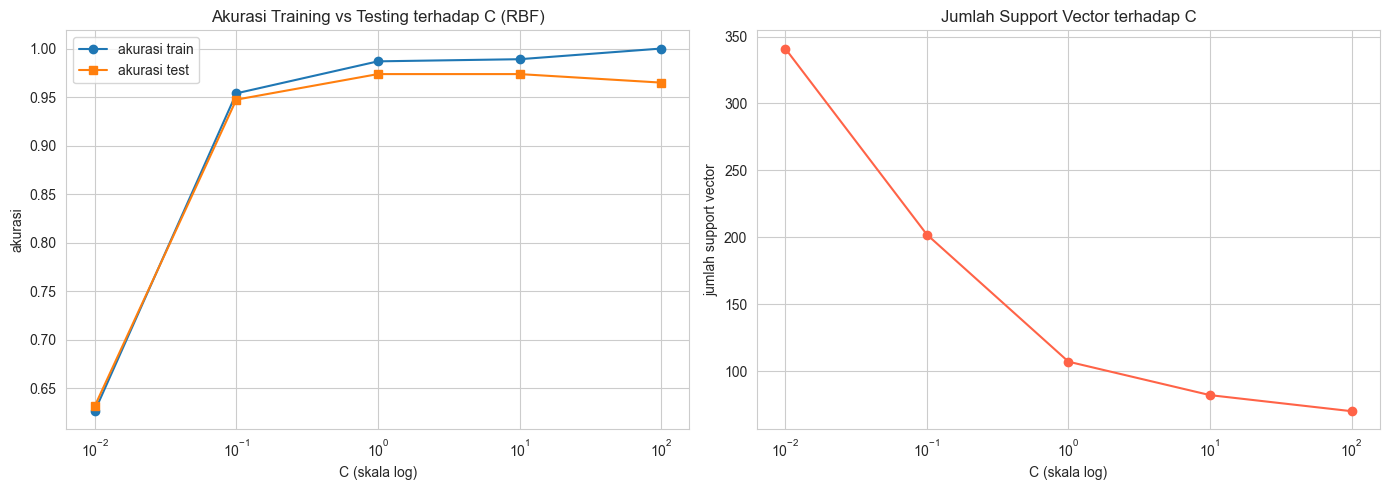

     C  support_vector  akurasi_train  akurasi_test  selisih_train_test
  0.01             341         0.6264        0.6316             -0.0052
  0.10             202         0.9538        0.9474              0.0065
  1.00             107         0.9868        0.9737              0.0131
 10.00              82         0.9890        0.9737              0.0153
100.00              70         1.0000        0.9649              0.0351


In [22]:
# Plot grafik akurasi training vs testing terhadap nilai C (gunakan sumbu x logaritmik) dalam satu chart.
# Amati pada nilai C berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].semilogx(hasil_C['C'], hasil_C['akurasi_train'], marker='o', label='akurasi train')
ax[0].semilogx(hasil_C['C'], hasil_C['akurasi_test'], marker='s', label='akurasi test')
ax[0].set_title('Akurasi Training vs Testing terhadap C (RBF)')
ax[0].set_xlabel('C (skala log)')
ax[0].set_ylabel('akurasi')
ax[0].legend()

# jumlah support vector ikut diplot karena ini indikator langsung lebarnya margin:
# C kecil = margin lebar = support vector banyak, C besar = margin sempit = support vector sedikit
ax[1].semilogx(hasil_C['C'], hasil_C['support_vector'], marker='o', color='tomato')
ax[1].set_title('Jumlah Support Vector terhadap C')
ax[1].set_xlabel('C (skala log)')
ax[1].set_ylabel('jumlah support vector')

plt.tight_layout()
plt.show()

print(hasil_C[['C', 'support_vector', 'akurasi_train', 'akurasi_test', 'selisih_train_test']].round(4).to_string(index=False))


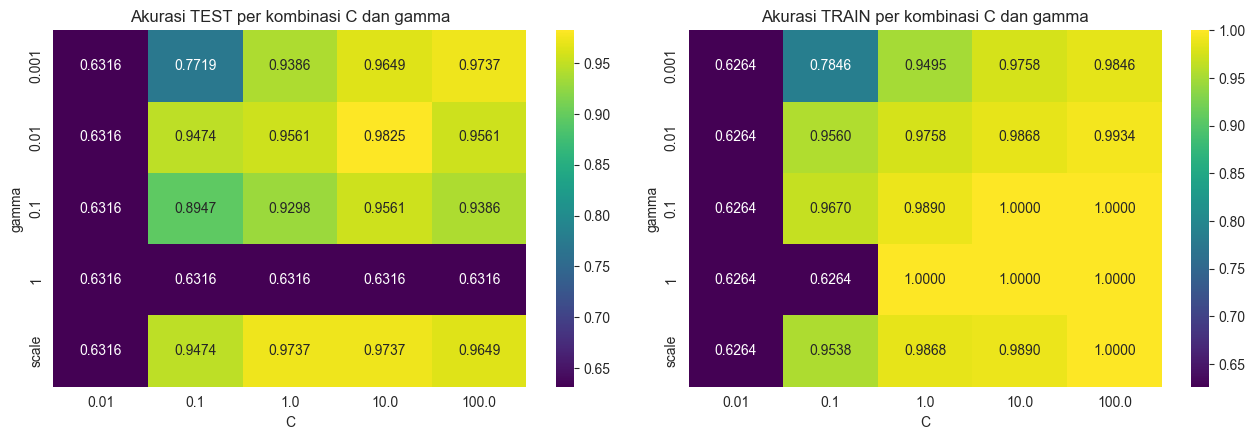

kombinasi terbaik di test -> gamma = 0.01 | C = 10.0 | akurasi test = 0.9825 | akurasi train = 0.9868

kombinasi yang akurasi train-nya 1.0 (hafal data train) : 6 dari 25


In [23]:
# README tugas ini juga menyinggung pengaruh gamma, jadi saya coba grid kecil C lawan gamma
list_gamma = ['scale', 0.001, 0.01, 0.1, 1]

grid = []
for g in list_gamma:
    for c in list_C:
        model = SVC(kernel='rbf', C=c, gamma=g, random_state=42)
        model.fit(X_train_scaled, y_train)
        grid.append({
            'gamma': str(g),
            'C': c,
            'akurasi_train': model.score(X_train_scaled, y_train),
            'akurasi_test': model.score(X_test_scaled, y_test),
        })

grid = pd.DataFrame(grid)
tabel_test = grid.pivot(index='gamma', columns='C', values='akurasi_test')
tabel_train = grid.pivot(index='gamma', columns='C', values='akurasi_train')

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(tabel_test, annot=True, fmt='.4f', cmap='viridis', ax=ax[0])
ax[0].set_title('Akurasi TEST per kombinasi C dan gamma')
sns.heatmap(tabel_train, annot=True, fmt='.4f', cmap='viridis', ax=ax[1])
ax[1].set_title('Akurasi TRAIN per kombinasi C dan gamma')
plt.tight_layout()
plt.show()

terbaik = grid.loc[grid['akurasi_test'].idxmax()]
print('kombinasi terbaik di test -> gamma =', terbaik['gamma'], '| C =', terbaik['C'],
      '| akurasi test =', round(terbaik['akurasi_test'], 4),
      '| akurasi train =', round(terbaik['akurasi_train'], 4))
print()
print('kombinasi yang akurasi train-nya 1.0 (hafal data train) :',
      (grid['akurasi_train'] == 1.0).sum(), 'dari', len(grid))


In [24]:
# cek langsung seberapa penting scaling buat SVM, karena ini salah satu fokus tugas
banding_scaling = []
for kernel in ['linear', 'rbf']:
    for pakai_scaling in [True, False]:
        Xtr = X_train_scaled if pakai_scaling else X_train.values
        Xte = X_test_scaled if pakai_scaling else X_test.values
        model = SVC(kernel=kernel, C=1, gamma='scale', random_state=42)
        model.fit(Xtr, y_train)
        p = model.predict(Xte)
        banding_scaling.append({
            'kernel': kernel,
            'scaling': 'pakai' if pakai_scaling else 'tanpa',
            'support_vector': model.support_vectors_.shape[0],
            'akurasi_test': accuracy_score(y_test, p),
            'recall_ganas': recall_score(y_test, p, pos_label=1, zero_division=0),
            'f1_ganas': f1_score(y_test, p, pos_label=1, zero_division=0),
        })

pd.DataFrame(banding_scaling).round(4)


,kernel,scaling,support_vector,akurasi_test,recall_ganas,f1_ganas
0,linear,pakai,38,0.9649,0.9048,0.9500
1,linear,tanpa,45,0.9211,0.8333,0.8861
2,rbf,pakai,107,0.9737,0.9286,0.9630
3,rbf,tanpa,120,0.9035,0.7381,0.8493


# 4. Evaluasi Model

In [25]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model kernel Linear dan RBF.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
def ringkas_metrik(nama, y_asli, y_pred):
    return {
        'model': nama,
        'accuracy': accuracy_score(y_asli, y_pred),
        'precision_ganas': precision_score(y_asli, y_pred, pos_label=1, zero_division=0),
        'recall_ganas': recall_score(y_asli, y_pred, pos_label=1, zero_division=0),
        'f1_ganas': f1_score(y_asli, y_pred, pos_label=1, zero_division=0),
        'f1_macro': f1_score(y_asli, y_pred, average='macro', zero_division=0),
    }


perbandingan = pd.DataFrame([
    ringkas_metrik('SVM Linear (C=1)', y_test, pred_linear),
    ringkas_metrik('SVM RBF (C=1)', y_test, pred_rbf),
])
perbandingan.set_index('model').round(4)


,accuracy,precision_ganas,recall_ganas,f1_ganas,f1_macro
model,,,,,
SVM Linear (C=1),0.9649,1.0,0.9048,0.950,0.9615
SVM RBF (C=1),0.9737,1.0,0.9286,0.963,0.9713


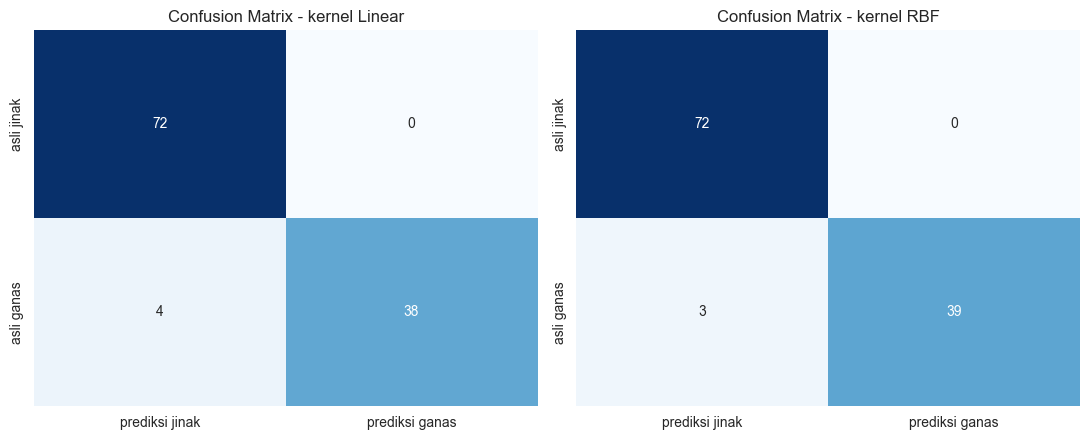

Linear  -> TN = 72 | FP = 0 | FN = 4 | TP = 38
         4 tumor ganas lolos terdeteksi sebagai jinak (false negative)
RBF     -> TN = 72 | FP = 0 | FN = 3 | TP = 39
         3 tumor ganas lolos terdeteksi sebagai jinak (false negative)


In [26]:
# Tampilkan Confusion Matrix untuk model kernel Linear dan RBF dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (nama, pred) in zip(axes, [('Linear', pred_linear), ('RBF', pred_rbf)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['prediksi jinak', 'prediksi ganas'],
                yticklabels=['asli jinak', 'asli ganas'])
    ax.set_title('Confusion Matrix - kernel ' + nama)
plt.tight_layout()
plt.show()

for nama, pred in [('Linear', pred_linear), ('RBF', pred_rbf)]:
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    print(nama.ljust(7), '-> TN =', tn, '| FP =', fp, '| FN =', fn, '| TP =', tp)
    print('        ', fn, 'tumor ganas lolos terdeteksi sebagai jinak (false negative)')


kernel linear -> support vector per kelas : [19 19] | total : 38
kernel rbf    -> support vector per kelas : [50 57] | total : 107

jumlah data train : 455
porsi data train yang jadi support vector :
  linear : 8.35 %
  rbf    : 23.52 %


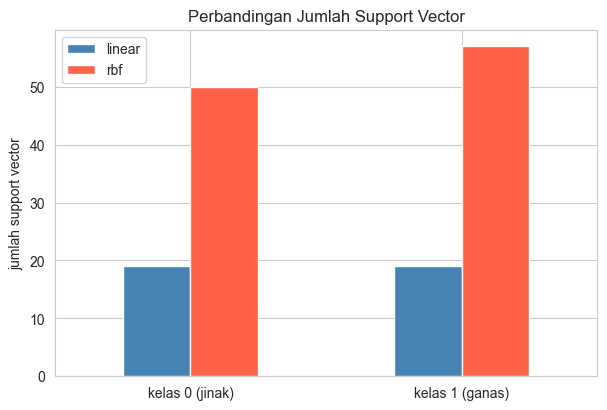

In [27]:
# Tampilkan jumlah support vectors dari model dengan performa terbaik (atribut model.support_vectors_ atau model.n_support_).
# Bandingkan jumlah support vectors antara model Linear dan RBF.
print('kernel linear -> support vector per kelas :', svm_linear.n_support_,
      '| total :', svm_linear.support_vectors_.shape[0])
print('kernel rbf    -> support vector per kelas :', svm_rbf.n_support_,
      '| total :', svm_rbf.support_vectors_.shape[0])
print()
print('jumlah data train :', X_train_scaled.shape[0])
print('porsi data train yang jadi support vector :')
print('  linear :', round(svm_linear.support_vectors_.shape[0] / X_train_scaled.shape[0] * 100, 2), '%')
print('  rbf    :', round(svm_rbf.support_vectors_.shape[0] / X_train_scaled.shape[0] * 100, 2), '%')

jumlah_sv = pd.DataFrame({
    'linear': svm_linear.n_support_,
    'rbf': svm_rbf.n_support_,
}, index=['kelas 0 (jinak)', 'kelas 1 (ganas)'])

jumlah_sv.plot(kind='bar', color=['steelblue', 'tomato'], rot=0, figsize=(7, 4.5))
plt.title('Perbandingan Jumlah Support Vector')
plt.ylabel('jumlah support vector')
plt.show()


variansi yang tertahan 2 komponen : [0.4459 0.1855] | total : 0.6314


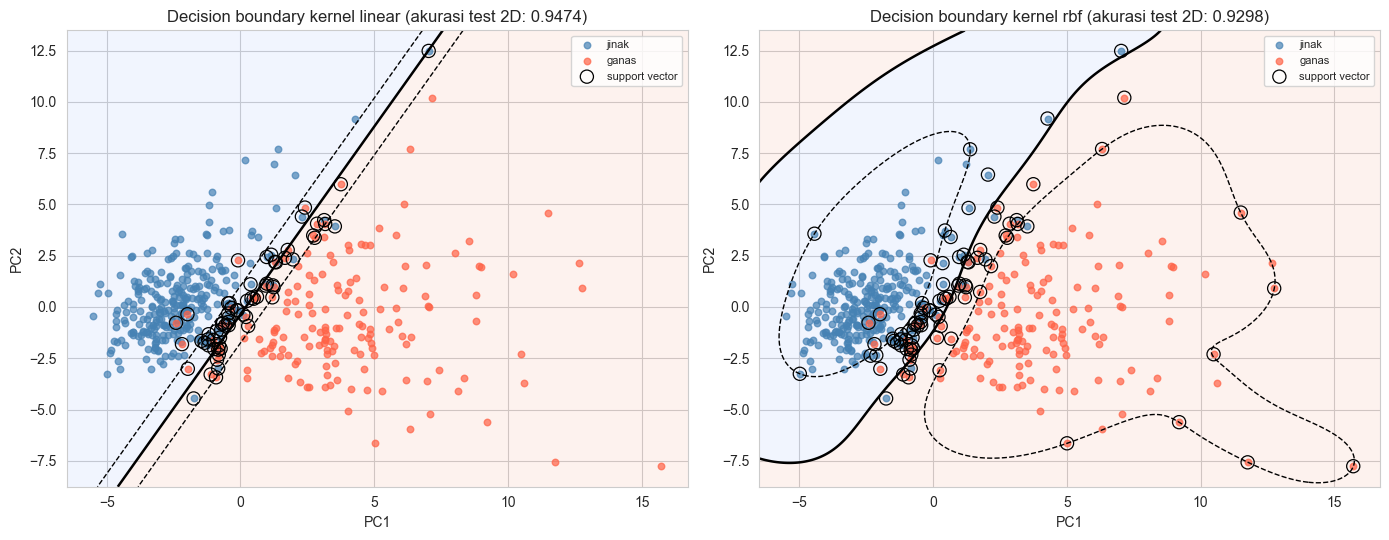

In [28]:
# Jika memungkinkan, pilih dua fitur (atau reduksi dimensi dengan PCA ke 2D) lalu visualisasikan decision boundary
# beserta margin dan support vectors dari model terbaik.
# data aslinya 30 dimensi jadi gak bisa digambar langsung. di sini datanya diringkas dulu ke 2 komponen
# utama pakai PCA, terus SVM dilatih ulang di ruang 2D itu. jadi ini model terpisah yang cuma buat
# ilustrasi bentuk decision boundary, bukan model yang dievaluasi di bagian 4.
pca = PCA(n_components=2, random_state=42)
Xtr_pca = pca.fit_transform(X_train_scaled)
Xte_pca = pca.transform(X_test_scaled)

print('variansi yang tertahan 2 komponen :', pca.explained_variance_ratio_.round(4),
      '| total :', round(pca.explained_variance_ratio_.sum(), 4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, kernel in zip(axes, ['linear', 'rbf']):
    model_2d = SVC(kernel=kernel, C=1, gamma='scale', random_state=42)
    model_2d.fit(Xtr_pca, y_train)

    x_min, x_max = Xtr_pca[:, 0].min() - 1, Xtr_pca[:, 0].max() + 1
    y_min, y_max = Xtr_pca[:, 1].min() - 1, Xtr_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
    Z = model_2d.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z > 0, alpha=0.12, cmap='coolwarm')
    # garis tengah decision boundary (0) plus dua garis margin (-1 dan +1)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors='k',
               linestyles=['--', '-', '--'], linewidths=[1, 1.8, 1])

    ax.scatter(Xtr_pca[y_train == 0, 0], Xtr_pca[y_train == 0, 1], s=22,
               c='steelblue', label='jinak', alpha=0.7)
    ax.scatter(Xtr_pca[y_train == 1, 0], Xtr_pca[y_train == 1, 1], s=22,
               c='tomato', label='ganas', alpha=0.7)
    ax.scatter(model_2d.support_vectors_[:, 0], model_2d.support_vectors_[:, 1],
               s=90, facecolors='none', edgecolors='black', linewidths=0.9,
               label='support vector')

    ax.set_title('Decision boundary kernel ' + kernel +
                 ' (akurasi test 2D: ' + str(round(model_2d.score(Xte_pca, y_test), 4)) + ')')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()


# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa SVM dengan kernel Linear vs RBF. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian, dikaitkan dengan bentuk sebaran data pada EDA?
- Jelaskan temuan dari eksperimen regularisasi (nilai `C`). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Bandingkan jumlah support vectors antara model Linear dan RBF. Apa hubungan jumlah support vectors dengan kompleksitas batas keputusan yang terbentuk?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

Dataset ini jauh lebih enak dikerjakan dibanding dataset bankruptcy di tugas Decision Tree. Kelasnya cukup seimbang (357 jinak lawan 212 ganas, sekitar 1 : 1.68), jadi accuracy masih lumayan bisa dipercaya di sini. Preprocessing-nya juga ringan, cuma buang `Unnamed: 32` yang isinya NaN di semua 569 baris (itu efek koma nyangkut di akhir tiap baris csv-nya, bukan fitur beneran) dan buang `id` yang cuma nomor pasien.

**Kernel Linear vs RBF.** RBF sedikit lebih unggul: akurasi test 0.9737 lawan 0.9649, F1 kelas ganas 0.9630 lawan 0.9500. Tapi kalau dilihat dari confusion matrix, bedanya cuma satu pasien. Linear meloloskan 4 tumor ganas sebagai jinak, RBF meloloskan 3. Dari 114 prediksi di test set, yang beda antara kedua kernel cuma 3. Jadi menurut saya belum bisa dibilang RBF benar-benar lebih baik, apalagi test set-nya cuma 114 baris di mana satu pasien saja sudah menggeser akurasi sekitar 0.0088.

Yang menurut saya lebih menarik, precision kelas ganas dua-duanya **1.0000**, false positive-nya nol. Artinya semua kesalahan model ini jatuh ke arah false negative, yaitu tumor ganas yang dikira jinak. Untuk kasus medis arah kesalahan ini justru yang paling bahaya, jadi kalau model ini beneran dipakai, saya lebih rela precision turun asal recall naik.

Bahwa kernel linear saja sudah bisa dapat 0.9649 memberi petunjuk datanya memang hampir bisa dipisah garis lurus setelah discaling. Ini cocok dengan scatter plot di bagian EDA, di mana kelas jinak dan ganas sudah kelihatan mengumpul di dua daerah berbeda walaupun batasnya agak bertabrakan di tengah.

**Jumlah support vector.** Bedanya besar: linear cuma butuh 38 support vector (19 per kelas, 8.35% dari 455 data train), sedangkan RBF butuh 107 (50 dan 57, 23.52%). Masuk akal karena kernel linear cuma perlu menentukan satu bidang datar, sedangkan RBF membentuk batas yang melengkung mengikuti sebaran data, jadi butuh lebih banyak titik acuan di sekitar batas. Efek sampingnya model RBF lebih berat dan lebih gampang ikut-ikutan noise.

**Eksperimen nilai C.** Di sini polanya paling jelas. Di `C=0.01` akurasi test-nya 0.6316 dan recall kelas ganas **0**, jadi model menebak semua pasien jinak. Angka 0.6316 itu persis proporsi kelas jinak di test set (72 dari 114), jadi modelnya benar-benar gak belajar apa-apa. Penyebabnya C kecil berarti hukuman untuk kesalahan sangat ringan, marginnya jadi selebar-lebarnya sampai menelan semua data, dan buktinya support vector-nya 341 dari 455 (75%). Ini kasus underfitting.

Naik ke `C=0.1` akurasi langsung lompat ke 0.9474, lalu puncaknya di `C=1` dan `C=10` yang sama-sama 0.9737. Di `C=100` akurasi train menyentuh 1.0000 tapi akurasi test malah turun ke 0.9649. Jadi gejala overfitting mulai muncul setelah `C=10`. Cirinya kelihatan dari selisih train dikurangi test yang naik terus: -0.0052, 0.0065, 0.0131, 0.0153, lalu melonjak ke 0.0351. Jumlah support vector-nya juga turun terus dari 341 ke 70, artinya marginnya makin sempit dan model makin memaksakan diri memisahkan setiap titik data train.

Dari grid kecil C lawan gamma, kombinasi terbaik di test adalah `gamma=0.01` dengan `C=10`, akurasi 0.9825. Tapi 6 dari 25 kombinasi sudah mencapai akurasi train 1.0000, dan itu yang perlu diwaspadai: gamma besar bikin tiap titik data punya pengaruh yang sangat lokal sehingga model gampang hafal data training.

**Pengaruh scaling.** Ini yang paling saya ingin buktikan karena jadi fokus tugasnya, dan hasilnya memang tegas. Tanpa scaling, akurasi test kernel RBF jatuh dari 0.9737 ke 0.9035 dan recall kelas ganasnya anjlok dari 0.9286 ke 0.7381. Kernel linear juga turun tapi gak separah itu, dari 0.9649 ke 0.9211.

Alasannya kelihatan dari pengecekan rentang fitur di bagian EDA: `area_worst` rentangnya 4068.8 sedangkan `fractal_dimension_se` cuma 0.0289, bedanya sekitar 140 ribu kali. Kernel RBF hitungannya murni jarak kuadrat antar titik, jadi kalau fiturnya gak disamakan skalanya, jarak antar pasien praktis ditentukan oleh `area_worst` sendirian dan 29 fitur lain nyaris gak ngaruh. Kernel linear lebih tahan karena masih bisa mengimbangi dengan memberi bobot kecil ke fitur berskala besar, walaupun tetap saja hasilnya lebih jelek. Ini sejalan dengan temuan saya di tugas KNN kemarin, algoritma yang kerjanya berbasis jarak selalu butuh scaling.

Terakhir soal visualisasi decision boundary, dua komponen PCA yang saya pakai cuma menahan 63.14% variansi dari 30 fitur asli. Jadi gambar itu enak dilihat untuk membandingkan bentuk batas linear yang lurus dengan batas RBF yang melengkung, tapi jangan dijadikan patokan performa, karena hampir 37% informasinya hilang waktu diringkas ke 2 dimensi.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba kernel Polynomial, melakukan hyperparameter tuning dengan GridSearchCV, atau membandingkan dengan model lain), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Model terbaik dari perbandingan utama adalah **SVM kernel RBF dengan `C=1` dan `gamma='scale'`**, dengan akurasi test 0.9737, precision kelas ganas 1.0000, recall 0.9286, F1 0.9630, dan F1 macro 0.9713. Kernel linear hasilnya sedikit di bawahnya (akurasi 0.9649, F1 0.9500) tapi selisihnya cuma satu pasien, jadi kalau butuh model yang ringan dan gampang dijelaskan, linear sebenarnya sudah cukup, apalagi support vector-nya jauh lebih sedikit (38 lawan 107).

Dari tiga hal yang diuji, urutan pengaruhnya menurut saya: **scaling paling menentukan**, lalu **nilai C**, dan **pilihan kernel paling kecil pengaruhnya**. Tanpa scaling, RBF yang tadinya paling bagus malah jadi yang paling jelek (0.9035). Nilai C mengubah hasil dari model yang gak belajar sama sekali di `C=0.01` sampai model yang mulai overfitting di `C=100`. Sementara beda linear dan RBF cuma menggeser 3 dari 114 prediksi.

Catatan yang menurut saya paling penting, angka akurasi 0.9737 itu kelihatan tinggi tapi masih menyisakan 3 tumor ganas yang lolos terdeteksi sebagai jinak. Karena precision-nya sudah 1.0000, sebetulnya masih ada ruang untuk menukar sedikit precision demi recall, dan untuk kasus kanker pertukaran itu layak dilakukan.

Sarannya:
1. Pemilihan `C` dan `gamma` sebaiknya pakai `GridSearchCV` dengan stratified k-fold cross validation, bukan dipilih dari akurasi test seperti yang saya lakukan. Sekarang test set ikut dipakai buat memilih hyperparameter, jadi angka 0.9825 dari grid itu kemungkinan agak optimistis.
2. Karena kesalahannya semua berupa false negative, threshold keputusannya bisa digeser pakai `decision_function` atau `probability=True` supaya recall kelas ganas naik. Bisa juga pakai `class_weight='balanced'` supaya salah menebak tumor ganas dihukum lebih berat.
3. Coba kernel lain seperti `poly` dan `sigmoid` sebagai pembanding, supaya kesimpulan soal "datanya hampir linear" lebih kuat dasarnya.
4. Fiturnya 30 dan banyak yang saling berkorelasi tinggi (`radius`, `perimeter`, dan `area` praktis mengukur hal yang sama). Bisa dicoba seleksi fitur atau PCA sebagai input model, bukan cuma buat visualisasi, buat lihat apakah performanya tetap dengan fitur yang lebih sedikit.
5. Test set-nya cuma 114 baris sehingga satu pasien saja menggeser akurasi 0.0088. Untuk kesimpulan yang lebih meyakinkan, hasilnya sebaiknya dilaporkan sebagai rata-rata dan simpangan baku dari cross validation, bukan dari satu kali split.